In [5]:
import torch
import random
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpmath import hyp2f0
%matplotlib inline

In [6]:
words = open('names.txt','r').read().splitlines()
words[:7]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia']

In [7]:
len(words)

32033

In [8]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [21]:

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
"""
we are taking 3 chars as input and trying to guess the fourth one
"""

In [23]:
random.seed(80)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182486, 3]) torch.Size([182486])
torch.Size([22935, 3]) torch.Size([22935])
torch.Size([22725, 3]) torch.Size([22725])


In [24]:
C = torch.randn((27,2))
"""
using two dimensions that x,y for simplicity , we have 27 char
"""

In [29]:
emb = C[Xtr]

"""
instead of using one hot representation we are just directly using index to
get the x,y co ordinates of the character
"""
emb.shape

torch.Size([182486, 3, 2])

In [40]:
some1 =torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],dim=1).shape
some2 = torch.cat(torch.unbind(emb,1),1).shape
"""
This can be done to convert [X,3,2] embedding matrix into [X,6] matrix
so that we can multiply it to weight [6,Y] matrix Y is the number of neurons
But we will use view which is highly efficient since it doesnt create any new tensors
but cat will do.
view is highly efficient since it doesnt use any extra space
Rule is that when we multiply the given input dimensions their product
should match the number of elements . we can pass -1 , -1 means it will calculate that number
itself by dividing the rest product with actual product
"""
some1,some2

(torch.Size([182486, 6]), torch.Size([182486, 6]))

In [48]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

# 100 neurons each with 6 weights

In [47]:
h =  torch.tanh(emb.view(-1,6) @ W1 + b1)

In [ ]:
"""
X,Y are variables in this context .
lets see what is h , emb is now [X,6] matrix where x in variable depends on number of input
and W1 is the weights of neurons , here we took Y neurons (can take any , here Y=100 )
since it is a hyper parameter, Whats happens is ---
we have 6 co ordinates for 3 chars for each example , in W1 we have Y neurons each with six weights
when we multiply the first row of emb with first col of W1 , we get a singe number
that is w11*x1 + w12*y2 +  w13*x2 + w14*y2 +  w15*x3 + w16*y3
wij corresponds to jth weight of ith neuron . SO when we multiply like this the whole matrix gets converted to
[X,Y] or [X,100] here . Now we will add basis to each of the element
b1 is a row vector with random values when we do  emb.view(-1,6) @ W1 + b1 . the Broadcasting works
X , 100   so when we dont have a dimension pytorch puts 1 in that space and the b1 matrices
  , 100   gets copied vertically . the row duplicates itself X times .
so now for every row of emb we add the row of b1 so now each elements gets
added to the corresponding basis.--> w11*x1 + w12*y2 +  w13*x2 + w14*y2 +  w15*x3 + w16*y3 + b1
Note that we can also use Exactly one neuron instead of 100 or Y
"""

In [50]:
h.shape

torch.Size([182486, 100])

In [44]:
emb

tensor([[[-0.3644, -0.5397],
         [-0.3644, -0.5397],
         [-0.3644, -0.5397]],

        [[-0.3644, -0.5397],
         [-0.3644, -0.5397],
         [-0.1504, -0.3219]],

        [[-0.3644, -0.5397],
         [-0.1504, -0.3219],
         [-1.2094, -0.4946]],

        ...,

        [[ 0.4627,  0.2087],
         [-1.0784, -2.4023],
         [ 0.4627,  0.2087]],

        [[-1.0784, -2.4023],
         [ 0.4627,  0.2087],
         [ 0.5848, -0.7396]],

        [[ 0.4627,  0.2087],
         [ 0.5848, -0.7396],
         [ 0.4627,  0.2087]]])

In [45]:
h

tensor([[-0.3880, -0.3826, -0.9995,  ..., -0.2774, -0.7292, -0.8395],
        [-0.4663, -0.2537, -0.9994,  ..., -0.0186, -0.7766, -0.8426],
        [ 0.4530,  0.1295, -0.9902,  ..., -0.0541, -0.0667, -0.5485],
        ...,
        [-0.4060,  0.9827, -1.0000,  ..., -0.0641, -0.9991, -0.9981],
        [-0.9160, -0.9994, -0.8881,  ...,  0.7191,  0.9168, -0.8715],
        [ 0.8367,  0.9349, -0.9962,  ..., -0.6045,  0.2166, -0.9935]])

In [51]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)
#100 is because of previous things and 27 is because of no of possible out puts

In [52]:
logits = h @ W2 + b2
logits.shape

torch.Size([182486, 27])

In [53]:
counts = logits.exp()

In [55]:
probs = counts / counts.sum(1,keepdim=True)
probs.shape

torch.Size([182486, 27])

In [ ]:
"""
Now we got a nice probability distribution,
each example has to predict a char out of 27 chars and each example has its own row
which is the probability distribution so that we can maximize the probability of needed element
and also to predict the next char we need this probability distribution
We will judge based on the loss function , that is neg loss log likelihood
we want to minimize the loss
"""

In [63]:
loss = -probs[torch.arange(Xtr.shape[0]),Ytr].log().mean()
loss.item()

16.858253479003906

In [64]:
# ------------ now made respectable :) ---------------

In [82]:
ltd = 10 # no of dimensions in look up table
ntanh = 200 # no of neurons in tan h layer
nouts = 27 # no of possible out comes
"""
The Learning rate , ltd , ntanh , regularization factor are all hyper parameters
we tweak this hyper parameter to find the best ones to train our mode;
"""

In [106]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((nouts,ltd),generator=g)
W1 = torch.randn((ltd*block_size,ntanh),generator=g)
b1 = torch.randn(ntanh , generator=g)
W2 = torch.randn((ntanh,nouts),generator=g)
b2 = torch.randn(nouts,generator = g)
parameters = [C,W1,b1,W2,b2]

In [107]:
sum(p.nelement() for p in parameters)

11897

In [108]:
for p in parameters:
    p.requires_grad = True
# need to explicitly mention that leaves requires grad since pytorch assumes not required

In [109]:
lre = torch.linspace(-3,0,100)
lrs = 10**lre

In [110]:
lri = []
stepi = []
lossi = []

In [111]:
for i in range(100):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,ltd*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

     # update
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    lri.append(lr)
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

15.955879211425781


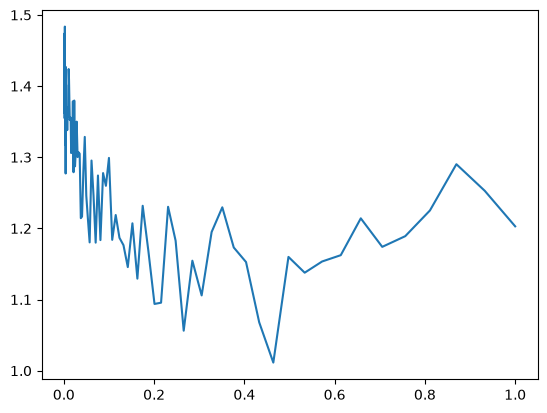

In [112]:
plt.plot(lri,lossi)

In [ ]:
"""
By doing this we esstimate a good learning rate , at 0.1 it is good afterwards it is unstable
Now we can do a learning rate decay that is lower the learning rate and find a good loss
higher the learning rate means we take bigger step and lower the learning rate small steps
The idea is to take big steps in the start even if we go in wrong direction sometimes
and take small steps as we approch towards goal.
"""

In [125]:
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,ltd*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

     # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    # track stats

    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.2546603679656982


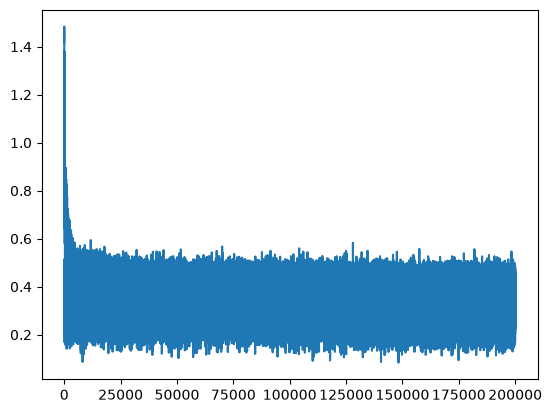

In [128]:
plt.plot(stepi, lossi)

In [ ]:
"""
YAY we surpassed our bigram model
loss of bigram model was 2.4 and this is 2.1 or  so its lot better than bigram model
Why F.cross entropy is better than doing manually , it is better because
it doesnt create new memory for all the intermediate tensor , it clusters up all the mathematical expression
Also it create or uses these fused kernal which avoids creating intermediate tensors for probs , counts etc
and also does the forward pass and backward pass much more efficiently
IT is also numerically well behaved , What if we have values like 100 or something
which we have to exponentiate , [-1,-2,1,100] here we cant calculate e**100 so what it kind of does is that
it does [-1,-2,1,100]-max([]) --> [-101,102,-99,0] now it calculates, doing this wont effect probs
because the extra e factor gets cancelled during counts/counts.sum() . here that e factor gets cancelled so
Can add or subtract anything from the logits .
"""

In [129]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,ltd*block_size) @ W1 + b1)
logits = h @ W2 + b2
devloss = F.cross_entropy(logits,Ydev)
devloss.item()

2.128068447113037

In [130]:
emb = C[Xte]
h = torch.tanh(emb.view(-1,ltd*block_size) @ W1 + b1)
logits = h @ W2 + b2
testloss = F.cross_entropy(logits,Yte)
testloss.item()

2.126312494277954

In [ ]:
"""

- **Overfitting**: train loss is much lower than dev loss. The model has enough capacity to memorize idiosyncrasies of the specific training examples (including their noise) rather than the general pattern, so it does great on data it's seen and worse on data it hasn't.
- **Underfitting**: train loss itself is still high (and dev loss is similarly high, or close to train loss). The model doesn't have enough capacity, or hasn't trained long enough, to even fit the training set well.
- Dev and test loss being close to each other is actually the **expected,
healthy** outcome once you've picked hyperparameters using the dev set —
it just means your three-way split is representative, not that anything is over/underfit.
 You use dev loss repeatedly while tuning, and test loss only once at the very end,
  precisely because tuning against test loss would leak information
   and make test loss an overfit estimate of true generalization.
Training set, DEv set , TESt set - 80% , 10%, 10%
out model trains on training set and sometimes checks its progress on dev set and
Tests very few times on test set , few times to avoid overfitting on test set
"""

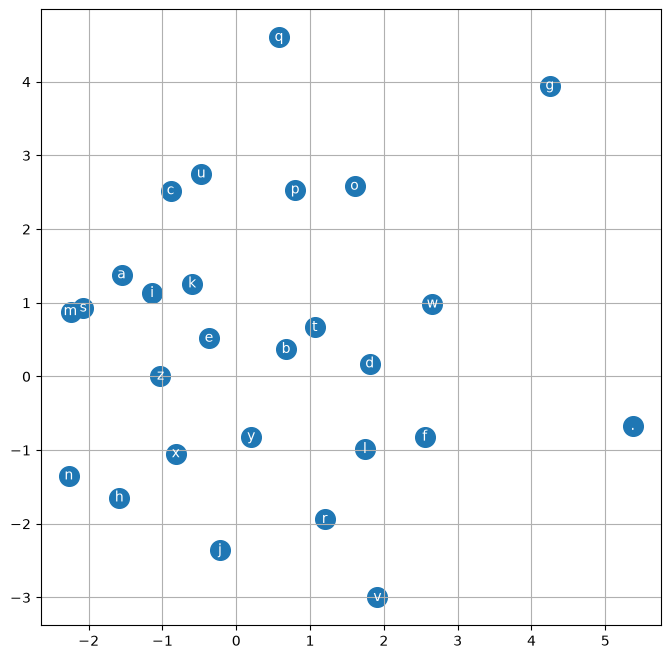

In [131]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [132]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [138]:
# sample from the model
for _ in range(20):

    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])] #(1,blockSize,d)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print("".join(out))

cunch.
brix.
aeden.
olly.
dan.
kayce.
yoanna.
ode.
taretzon.
jomi.
naiah.
xon.
athnileuno.
aabranceontee.
quineelaiferamayler.
ezas.
jowentlin.
banlu.
abacgrissey.
amorah.


In [ ]:
"""
Given 4 hyperparameters (ltd, ntanh, lr, weight_decay), full grid search is expensive. What actually works well at this scale:

Fix lr first, using the LR range test — it's cheap to find and mostly independent of the other three.
Sweep ntanh alone (fixing ltd at a reasonable default like 10), watching train/dev gap, to find a width where dev loss stops improving.
Sweep ltd alone at that chosen width, same diagnostic.
Only then introduce weight_decay if you still see a meaningful train/dev gap at your chosen ltd/ntanh.
Do one final short sweep re-checking lr at the final architecture, since capacity changes can shift the optimal LR slightly.
"""

In [ ]:
"""
================================================================================
THE PAINTER ANALOGY — reading this notebook as an automated portrait machine
================================================================================

THE SUBJECT (the data)
  Every name in names.txt is a "reference photo." We slide a 3-character
  window across each name and ask: given the last 3 characters the painter
  has already committed to canvas, what's the most likely next brushstroke
  (character)? X = the 3-character context, Y = the character that should
  come next. This is what build_dataset() is doing.

THE PALETTE (the embedding table C)
  Every one of the 27 possible characters ('.' plus a-z) gets its own tube
  of paint, and C stores the exact pigment recipe for each one: `ltd`
  independent properties per character (hue, saturation, warmth, texture...
  whatever the training process decides they should mean). C[Xtr] is just
  "look up the pigment recipe for these characters" -- not a hand-mixed
  approximation, a direct, exact lookup, which is why we use integer
  indexing here instead of a one-hot-matmul: it's mathematically identical
  but far cheaper.
  With ltd=2 (Cell 6), every character only gets 2 pigment properties --
  you can literally see this poverty of expression in Cell 37's scatter
  plot, where all 27 characters are squeezed onto a flat 2D sheet. With
  ltd=10 (Cell 22), each character gets 10 independent properties, letting
  the model distinguish much subtler roles the same letter can play
  depending on context.

LOADING THE BRUSH (concatenating the context into one input vector)
  A single canvas position depends on 3 characters of context, so we lay
  their 3 pigment recipes side by side into one long input vector via
  .view(-1, ltd*block_size). This is just physically arranging the 3
  paint tubes' worth of pigment into a single loaded brush-handle, ready
  to be pressed to canvas in one motion -- and .view() does this as a
  free reinterpretation of the same memory, not a new mixing step
  (unlike torch.cat, which actually would copy data).

THE STAMPING MACHINE (the hidden layer: W1, b1, tanh)
  Instead of one painter making one brushstroke at a time, imagine a
  stamping machine holding `ntanh` brushes (100, then 200) that all press
  onto the canvas simultaneously. Each brush has its own dip pattern --
  its own row of weights in W1 -- deciding exactly how much of each of
  the ltd*block_size pigment properties it draws from. Brush #12 might be
  heavily dipped in "is this a vowel" and almost ignore everything else;
  brush #47 might specialize in "did the previous two characters just
  repeat." Because every brush has an independently-tunable dip pattern,
  the machine can develop 100 or 200 completely different specialists,
  each responsible for a different subtle pattern in the data -- this is
  exactly what lets the network disentangle conflicting demands that a
  single brush (a single neuron) could never satisfy at once.

  The bristles themselves are not rigid -- tanh gives them flex. A rigid
  brush (no nonlinearity) can only stamp perfectly flat, straight blocks
  of color, and worse: stacking multiple rigid-brush stages on top of each
  other doesn't help at all, because pressing one rigid stamp after
  another is mathematically identical to pressing one single (bigger)
  rigid stamp -- linear-on-linear is still linear. tanh is what lets each
  brush bend its stroke into a smooth curve, which is the only reason
  adding more brushes (or more stages) buys you any additional expressive
  power at all. tanh also acts as a paint-flow regulator: it squashes
  every brush's output to strictly between -1 and 1, so no single
  overexcited brush can flood the canvas and drown out the other 99. The
  cost of this safety valve: a brush pushed to its limit (deep in
  saturation) stops being sensitive to correction -- its local slope
  flattens toward zero, so the Critic's feedback barely reaches it. A
  brush that's fully "dried out" like this is hard to adjust later, which
  is why how hard we initially press each brush (the initial scale of W1,
  b1) matters.

MIXING THE FINAL STROKE INTO A VERDICT (W2, b2, logits)
  The 100 (or 200) individual brush outputs (h) are not the final
  painting -- they're intermediate strokes. A second mixing stage (W2, b2)
  blends all of those strokes together into 27 final "how confident am I
  this is the next character" scores, one per possible character. These
  raw scores (logits) can be any real number, positive or negative, so
  they don't look like a probability yet.

TURNING CONFIDENCE INTO A PROBABILITY DISTRIBUTION (softmax)
  Exponentiating each logit (counts = logits.exp()) then dividing every
  row by its own total (probs = counts/counts.sum()) turns arbitrary
  confidence scores into a genuine distribution over 27 outcomes that
  sums to 1 -- "the machine's honest guess," expressed as a probability
  for every possible next brushstroke, not just its single favorite.
  F.cross_entropy does this exact same softmax step internally, plus the
  max-subtraction trick (subtract the largest logit before exponentiating,
  which changes nothing about the final probabilities but prevents
  overflow), plus it fuses all these steps into one kernel instead of
  building separate counts/probs/log tensors -- purely an efficiency and
  stability upgrade, not a different computation.

THE ART CRITIC (the loss)
  The Critic looks at the one probability the model assigned to the
  *actual* next character and asks: how surprised should I be that this
  is what the model predicted? -log(probability) is exactly that
  "surprise" -- near 0 if the model was confidently correct, huge if the
  model assigned almost no probability to the character that actually
  came next. Averaging this surprise across the whole batch gives one
  single number (the loss) summarizing how bad the entire simultaneous
  stamp was.

ASSIGNING BLAME (backpropagation)
  loss.backward() is the Critic tracing every bit of that surprise
  backward through the whole chain -- through the final mix (W2, b2),
  through each brush's tanh bend, through each brush's dip pattern (W1,
  b1), and even back into the pigment recipes themselves (C) -- using the
  chain rule to work out exactly how much *each individual weight*
  contributed to the final disappointment. This is why we zero every
  parameter's .grad before calling backward(): each round of blame has to
  be freshly and independently computed, not accumulated on top of the
  previous round's blame.

REPAINTING, SLIGHTLY BETTER (the update step)
  p.data -= lr * p.grad nudges every single weight -- every pigment
  property, every brush's dip pattern, every mixing weight -- a tiny step
  in the direction that would have reduced the Critic's surprise. `lr`
  controls how large that nudge is: too large and the machine overcorrects
  wildly from one canvas to the next (this is exactly what Cell 29's
  learning-rate sweep is diagnosing -- loss explodes past roughly lr=0.1);
  too small and it takes forever to improve. The lr decay in Cell 31
  (0.1 for the first 100k steps, 0.01 after) mirrors a real painter: broad,
  confident corrections early on while the composition is still rough, and
  small, careful refinements once the picture is mostly right.

WHY WE NEVER LET THE MACHINE STUDY THE FINAL EXAM (train/dev/test)
  We only ever compute gradients from Xtr/Ytr -- the machine never
  directly copies brushstrokes from Xdev or Xte. Dev loss is how we check
  its progress on canvases it hasn't directly practiced on, used
  repeatedly while we're still choosing hyperparameters like ltd and
  ntanh. Test loss is checked rarely, at the very end, as an honest
  final grade -- because if we kept re-tuning the machine based on the
  test score, the test set would stop being a fair measure of how well
  the machine generalizes to *truly* unseen canvases, the same way a
  student who's seen the final exam questions in advance doesn't have
  their real understanding measured by that exam anymore. Overfitting
  would show up here as train loss dropping much lower than dev loss --
  the machine getting suspiciously good at reproducing brushstrokes it's
  literally memorized, while getting no better (or worse) at painting
  anything new.

PAINTING FROM A BLANK CANVAS (sampling)
  Once trained, generation (Cell 39) runs the exact same machine forward
  with no Critic and no correction step -- just repeatedly: look up the
  pigment recipe for the last 3 characters, stamp with all the (now
  well-trained) brushes, mix into logits, turn into a probability
  distribution, then randomly draw the next character from that
  distribution (torch.multinomial) rather than always taking the most
  confident guess -- so the machine paints something new and specific
  each time, rather than replaying a single deterministic answer, while
  still being guided by everything its brushes learned about what
  plausible names look like.
================================================================================

"""